# Генерация шаблона для печати


In [3]:
%load_ext autoreload
%autoreload 2

import cv2
import matplotlib.pyplot as plt
from utils import generate_template

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


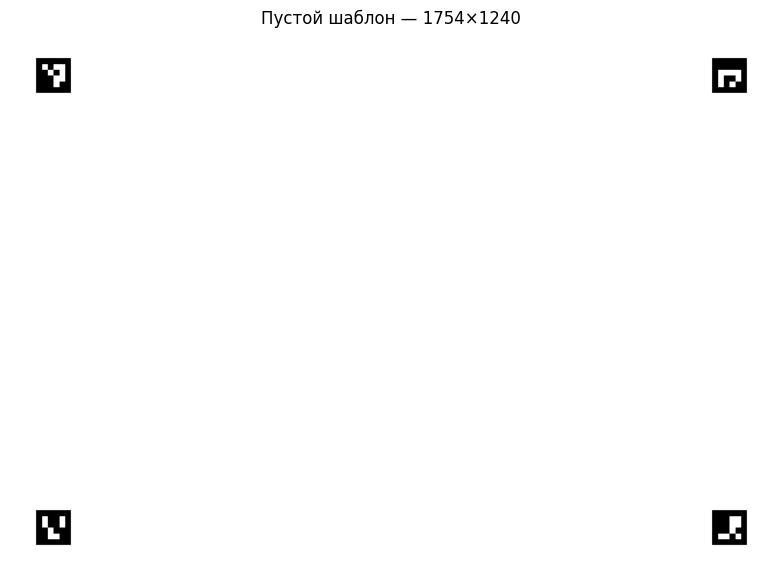

Сохранено: output\blank_template.png


In [18]:
result_blank = generate_template()

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result_blank["template"], cv2.COLOR_BGR2RGB))
h, w = result_blank["template"].shape[:2]
plt.title(f"Пустой шаблон — {w}×{h}")
plt.axis("off")
plt.show()

print(f"Сохранено: {result_blank['template_path']}")

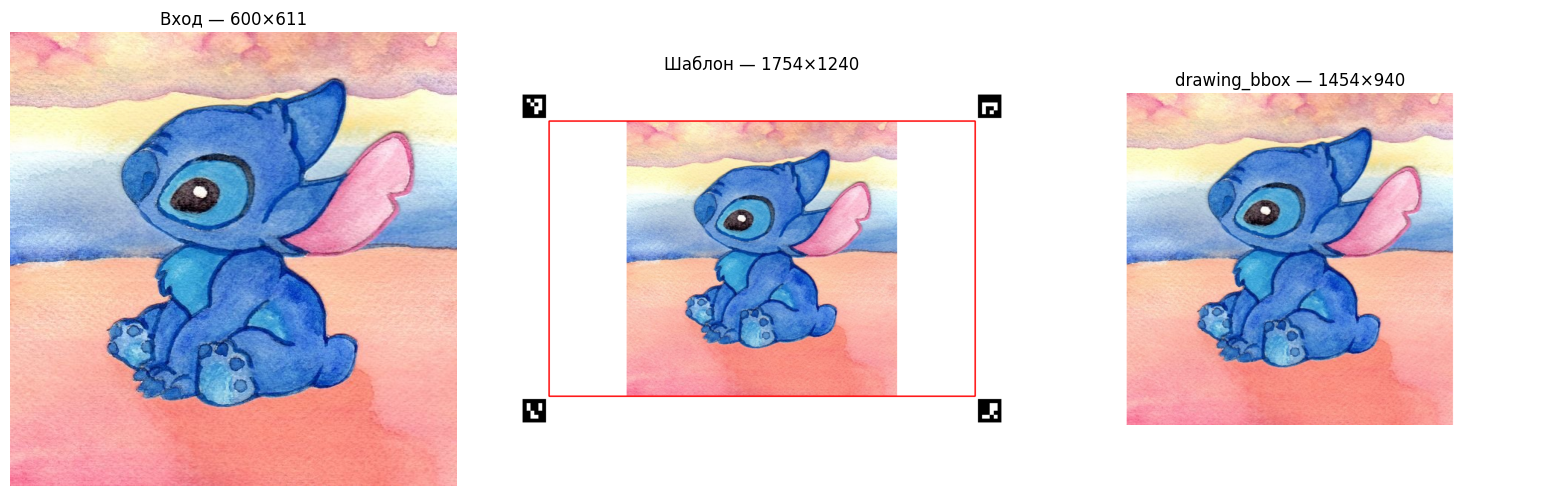

In [22]:
img_path = "input/img04_raw.jpg"

img_in = cv2.imread(img_path)
result = generate_template(img_path, content_scale=1)

h_in, w_in = img_in.shape[:2]
h_out, w_out = result["template"].shape[:2]
bx, by, bw, bh = result["meta"]["drawing_bbox"]

# шаблон с красной рамкой drawing_bbox
template_vis = result["template"].copy()
cv2.rectangle(template_vis, (bx, by), (bx + bw, by + bh), (0, 0, 255), 3)

# кроп по drawing_bbox
crop = result["template"][by : by + bh, bx : bx + bw]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(img_in, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Вход — {w_in}×{h_in}")
axes[1].imshow(cv2.cvtColor(template_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Шаблон — {w_out}×{h_out}")
axes[2].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"drawing_bbox — {bw}×{bh}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()